In [6]:
%load_ext autoreload
%autoreload 2

In [ ]:
# !PYTHONPATH=../src python ../main.py


Running Analysis for: 2008 Financial Crisis - Concentrated Financials
Time Horizon: 2007-01-01 to 2009-12-31
Confidence Level: 95.0%
  - Historical VaR (%):        -0.0554
  - Historical VaR ($):        $55,370.51
  - Parametric (Normal) VaR (%): 0.0647
  - Parametric (Normal) VaR ($): $64,682.79

Running Analysis for: 2008 Financial Crisis - Multi-Asset Diverse
Time Horizon: 2007-01-01 to 2009-12-31
Confidence Level: 95.0%
  - Historical VaR (%):        -0.0163
  - Historical VaR ($):        $16,342.88
  - Parametric (Normal) VaR (%): 0.0187
  - Parametric (Normal) VaR ($): $18,654.43


In [ ]:
# !PYTHONPATH=../src python ../src/stress_engine/monte_carlo.py

Executing standalone Monte Carlo stress tests...
Simulation results successfully serialized to disk.


In [ ]:
# !PYTHONPATH=../src python ../src/stress_engine/monte_carlo_shock.py

Executing Shock-Enabled Monte Carlo Stress Tests...
Shock simulation results successfully saved to synthetic_monte_carlo_shock_results.parquet


In [2]:
import sys
from pathlib import Path

# Setup path to include src/
src_path = Path("../src").resolve()
if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

from stress_engine.portfolio import PortfolioVaR


def run_portfolio_analysis() -> None:
    portfolios = [
        PortfolioVaR(
            name="2008 Financial Crisis - Concentrated Financials",
            tickers=["SPY", "C", "BAC", "XLF", "GS"],
            weights=[0.2, 0.2, 0.2, 0.2, 0.2],
            start_date="2007-01-01",
            end_date="2009-12-31",
            initial_capital=1_000_000,
            confidence_level=0.95,
        ),
        PortfolioVaR(
            name="2008 Financial Crisis - Multi-Asset Diverse",
            tickers=["SPY", "TLT", "GLD", "DBC"],
            weights=[0.4, 0.3, 0.2, 0.1],
            start_date="2007-01-01",
            end_date="2009-12-31",
            initial_capital=1_000_000,
            confidence_level=0.95,
        ),
    ]

    for port in portfolios:
        print("\n==================================================")
        print(f"Running Analysis for: {port.name}")
        print(f"Time Horizon: {port.start_date} to {port.end_date}")
        print("==================================================")

        metrics = port.run_analysis()

        print(f"Confidence Level: {port.confidence_level * 100}%")
        print(f"  - Historical VaR (%):        {metrics['hist_pct']:.4f}")
        print(
            f"  - Historical VaR ($):        ${abs(float(metrics['hist_dollar'])):,.2f}"
        )
        print(f"  - Parametric (Normal) VaR (%): {metrics['param_pct']:.4f}")
        print(
            f"  - Parametric (Normal) VaR ($): ${abs(float(metrics['param_dollar'])):,.2f}"
        )


run_portfolio_analysis()


Running Analysis for: 2008 Financial Crisis - Concentrated Financials
Time Horizon: 2007-01-01 to 2009-12-31
Confidence Level: 95.0%
  - Historical VaR (%):        -0.0554
  - Historical VaR ($):        $55,370.43
  - Parametric (Normal) VaR (%): 0.0647
  - Parametric (Normal) VaR ($): $64,682.77

Running Analysis for: 2008 Financial Crisis - Multi-Asset Diverse
Time Horizon: 2007-01-01 to 2009-12-31
Confidence Level: 95.0%
  - Historical VaR (%):        -0.0163
  - Historical VaR ($):        $16,342.77
  - Parametric (Normal) VaR (%): 0.0187
  - Parametric (Normal) VaR ($): $18,654.43


In [3]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

# Setup path to include src/
src_path = Path("../src").resolve()
if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

from stress_engine.monte_carlo import generate_parameter_grid, run_extended_monte_carlo


def run_standard_mc_pipeline() -> pd.DataFrame:
    grid = generate_parameter_grid()
    ledger: list[dict[str, float | str]] = []

    print("Executing standard standalone Monte Carlo stress tests...")
    for inst_name, profile in grid.items():
        prob, max_dds = run_extended_monte_carlo(profile, n_paths=2000, n_days=90)
        ledger.append(
            {
                "Institution": inst_name,
                "Annual_Vol": profile["annual_vol"],
                "Tail_DF": profile["t_df"],
                "GJR_Gamma": profile["gjr_gamma"],
                "Distress_Probability": prob,
                "Mean_Max_DD": float(np.mean(max_dds)),
                "P95_Max_DD": float(np.percentile(max_dds, 5)),
            }
        )

    df_out = pd.DataFrame(ledger)
    output_dir = Path("../data/raw")
    output_dir.mkdir(parents=True, exist_ok=True)
    output_file = output_dir / "synthetic_monte_carlo_results.parquet"

    df_out.to_parquet(output_file, index=False)
    print(f"Standard simulation results saved to: {output_file}")
    return df_out


df_standard_results = run_standard_mc_pipeline()
df_standard_results.head()

Executing standard standalone Monte Carlo stress tests...
Standard simulation results saved to: ../data/raw/synthetic_monte_carlo_results.parquet


,Institution,Annual_Vol,Tail_DF,GJR_Gamma,Distress_Probability,Mean_Max_DD,P95_Max_DD
0,Vol-Low_Tail-Fat_Asym-Low,0.1,3.5,0.01,0.0,-0.004099,-0.007926
1,Vol-Low_Tail-Fat_Asym-Norm,0.1,3.5,0.05,0.0,-0.004088,-0.008088
2,Vol-Low_Tail-Fat_Asym-High,0.1,3.5,0.15,0.0,-0.004033,-0.007852
3,Vol-Low_Tail-Norm_Asym-Low,0.1,8.0,0.01,0.0,-0.004278,-0.008013
4,Vol-Low_Tail-Norm_Asym-Norm,0.1,8.0,0.05,0.0,-0.004222,-0.007924


In [5]:
import sys
from pathlib import Path

import pandas as pd

# Setup path to include src/
src_path = Path("../src").resolve()
if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

from stress_engine.monte_carlo_shock import (
    generate_parameter_grid,
    run_shock_monte_carlo,
)


def run_shock_mc_pipeline() -> pd.DataFrame:
    grid = generate_parameter_grid()
    ledger: list[dict[str, float | str]] = []

    print("Executing Shock-Enabled Monte Carlo Stress Tests...")
    for inst_name, profile in grid.items():
        prob, max_dds = run_shock_monte_carlo(profile, n_paths=2000, n_days=90)
        ledger.append(
            {
                "Institution": inst_name,
                "Annual_Vol": profile["annual_vol"],
                "Tail_DF": profile["t_df"],
                "GJR_Gamma": profile["gjr_gamma"],
                "Distress_Probability": prob,
                "Mean_Max_DD": float(np.mean(max_dds)),
                "P95_Max_DD": float(np.percentile(max_dds, 5)),
            }
        )

    df_out = pd.DataFrame(ledger)
    output_dir = Path("../data/raw")
    output_dir.mkdir(parents=True, exist_ok=True)
    output_file = output_dir / "synthetic_monte_carlo_shock_results.parquet"

    df_out.to_parquet(output_file, index=False)
    print(f"Shock simulation results saved to: {output_file}")
    return df_out


df_shock_results = run_shock_mc_pipeline()
df_shock_results.sort_values(by="Distress_Probability", ascending=False).head(10)

Executing Shock-Enabled Monte Carlo Stress Tests...
Shock simulation results saved to: ../data/raw/synthetic_monte_carlo_shock_results.parquet


,Institution,Annual_Vol,Tail_DF,GJR_Gamma,Distress_Probability,Mean_Max_DD,P95_Max_DD
0,Vol-Low_Tail-Fat_Asym-Low,0.10,3.5,0.01,1.0,-0.426214,-0.428532
1,Vol-Low_Tail-Fat_Asym-Norm,0.10,3.5,0.05,1.0,-0.569853,-0.571680
2,Vol-Low_Tail-Fat_Asym-High,0.10,3.5,0.15,1.0,-0.790603,-0.791478
5,Vol-Low_Tail-Norm_Asym-High,0.10,8.0,0.15,1.0,-0.496482,-0.498551
10,Vol-Norm_Tail-Fat_Asym-Norm,0.20,3.5,0.05,1.0,-0.571354,-0.574962
9,Vol-Norm_Tail-Fat_Asym-Low,0.20,3.5,0.01,1.0,-0.428318,-0.433393
20,Vol-High_Tail-Fat_Asym-High,0.35,3.5,0.15,1.0,-0.792423,-0.795576
19,Vol-High_Tail-Fat_Asym-Norm,0.35,3.5,0.05,1.0,-0.573506,-0.579551
18,Vol-High_Tail-Fat_Asym-Low,0.35,3.5,0.01,1.0,-0.431308,-0.439693
14,Vol-Norm_Tail-Norm_Asym-High,0.20,8.0,0.15,1.0,-0.498433,-0.502559


In [ ]:
# shock_day = 30
# if n_days > shock_day:
#     tail_multiplier = (
#         3.0 / df
#     )  # Heavier tails (e.g., df=3.5) amplify the shock impact
#     shock_magnitude = -0.28 * (1.0 + gamma * 10.0) * tail_multiplier
#     z[:, shock_day] = shock_magnitude / (daily_vol * np.sqrt(dt))

# Institution	Annual_Vol	Tail_DF	GJR_Gamma	Distress_Probability	Mean_Max_DD	P95_Max_DD
# 0	Vol-Low_Tail-Fat_Asym-Low	0.1	3.5	0.01	0.0	-0.148706	-0.152296
# 1	Vol-Low_Tail-Fat_Asym-Norm	0.1	3.5	0.05	0.0	-0.173891	-0.177274
# 2	Vol-Low_Tail-Fat_Asym-High	0.1	3.5	0.15	0.0	-0.233642	-0.236819
# 3	Vol-Low_Tail-Norm_Asym-Low	0.1	8.0	0.01	0.0	-0.148900	-0.152399
# 4	Vol-Low_Tail-Norm_Asym-Norm	0.1	8.0	0.05	0.0	-0.173972	-0.177206
# 5	Vol-Low_Tail-Norm_Asym-High	0.1	8.0	0.15	0.0	-0.233699	-0.236963
# 6	Vol-Low_Tail-Thin_Asym-Low	0.1	30.0	0.01	0.0	-0.148828	-0.152374
# 7	Vol-Low_Tail-Thin_Asym-Norm	0.1	30.0	0.05	0.0	-0.174063	-0.177636
# 8	Vol-Low_Tail-Thin_Asym-High	0.1	30.0	0.15	0.0	-0.233741	-0.236798
# 9	Vol-Norm_Tail-Fat_Asym-Low	0.2	3.5	0.01	0.0	-0.151696	-0.158948

# Mean_man_DD has spiked, 24% - 15% shock simulation compared to 1.5% - 0.4% non-shock simulation. This is a significant increase in the probability of distress, indicating that the shock scenario has a substantial impact on the risk profile of the institutions being analyzed. Still below the 40% threshold for concern, but the increase is notable and warrants further investigation into the specific factors contributing to this heightened risk.

In [ ]:
# tail_multiplier = 4.0 / df
# shock_magnitude = -0.42 * (1.0 + gamma * 15.0) * tail_multiplier
# z[:, shock_day] = shock_magnitude / (daily_vol * np.sqrt(dt))

# daily_rets = -0.5 * (daily_vol**2) * dt + daily_vol * np.sqrt(dt) * z
# log_rets = np.hstack([np.zeros((n_paths, 1)), np.cumsum(daily_rets, axis=1)])
# price_paths = initial_price * np.exp(log_rets)

# rolling_max = np.maximum.accumulate(price_paths, axis=1)
# drawdowns = (price_paths - rolling_max) / rolling_max
# max_drawdowns = np.min(drawdowns, axis=1)

# breach_count = np.sum(max_drawdowns <= distress_threshold)
# return float(breach_count / n_paths), max_drawdowns

# 	Institution	Annual_Vol	Tail_DF	GJR_Gamma	Distress_Probability	Mean_Max_DD	P95_Max_DD
# 0	Vol-Low_Tail-Fat_Asym-Low	0.10	3.5	0.01	1.0	-0.426214	-0.428532
# 1	Vol-Low_Tail-Fat_Asym-Norm	0.10	3.5	0.05	1.0	-0.569853	-0.571680
# 2	Vol-Low_Tail-Fat_Asym-High	0.10	3.5	0.15	1.0	-0.790603	-0.791478
# 5	Vol-Low_Tail-Norm_Asym-High	0.10	8.0	0.15	1.0	-0.496482	-0.498551
# 10	Vol-Norm_Tail-Fat_Asym-Norm	0.20	3.5	0.05	1.0	-0.571354	-0.574962
# 9	Vol-Norm_Tail-Fat_Asym-Low	0.20	3.5	0.01	1.0	-0.428318	-0.433393
# 20	Vol-High_Tail-Fat_Asym-High	0.35	3.5	0.15	1.0	-0.792423	-0.795576
# 19	Vol-High_Tail-Fat_Asym-Norm	0.35	3.5	0.05	1.0	-0.573506	-0.579551
# 18	Vol-High_Tail-Fat_Asym-Low	0.35	3.5	0.01	1.0	-0.431308	-0.439693
# 14	Vol-Norm_Tail-Norm_Asym-High	0.20	8.0	0.15	1.0	-0.498433	-0.502559

Compiling path-wise maximum drawdowns across 3x3x3 grid for visualization...
Visualization successfully saved to '../monte_carlo_drawdown_distributions.png'


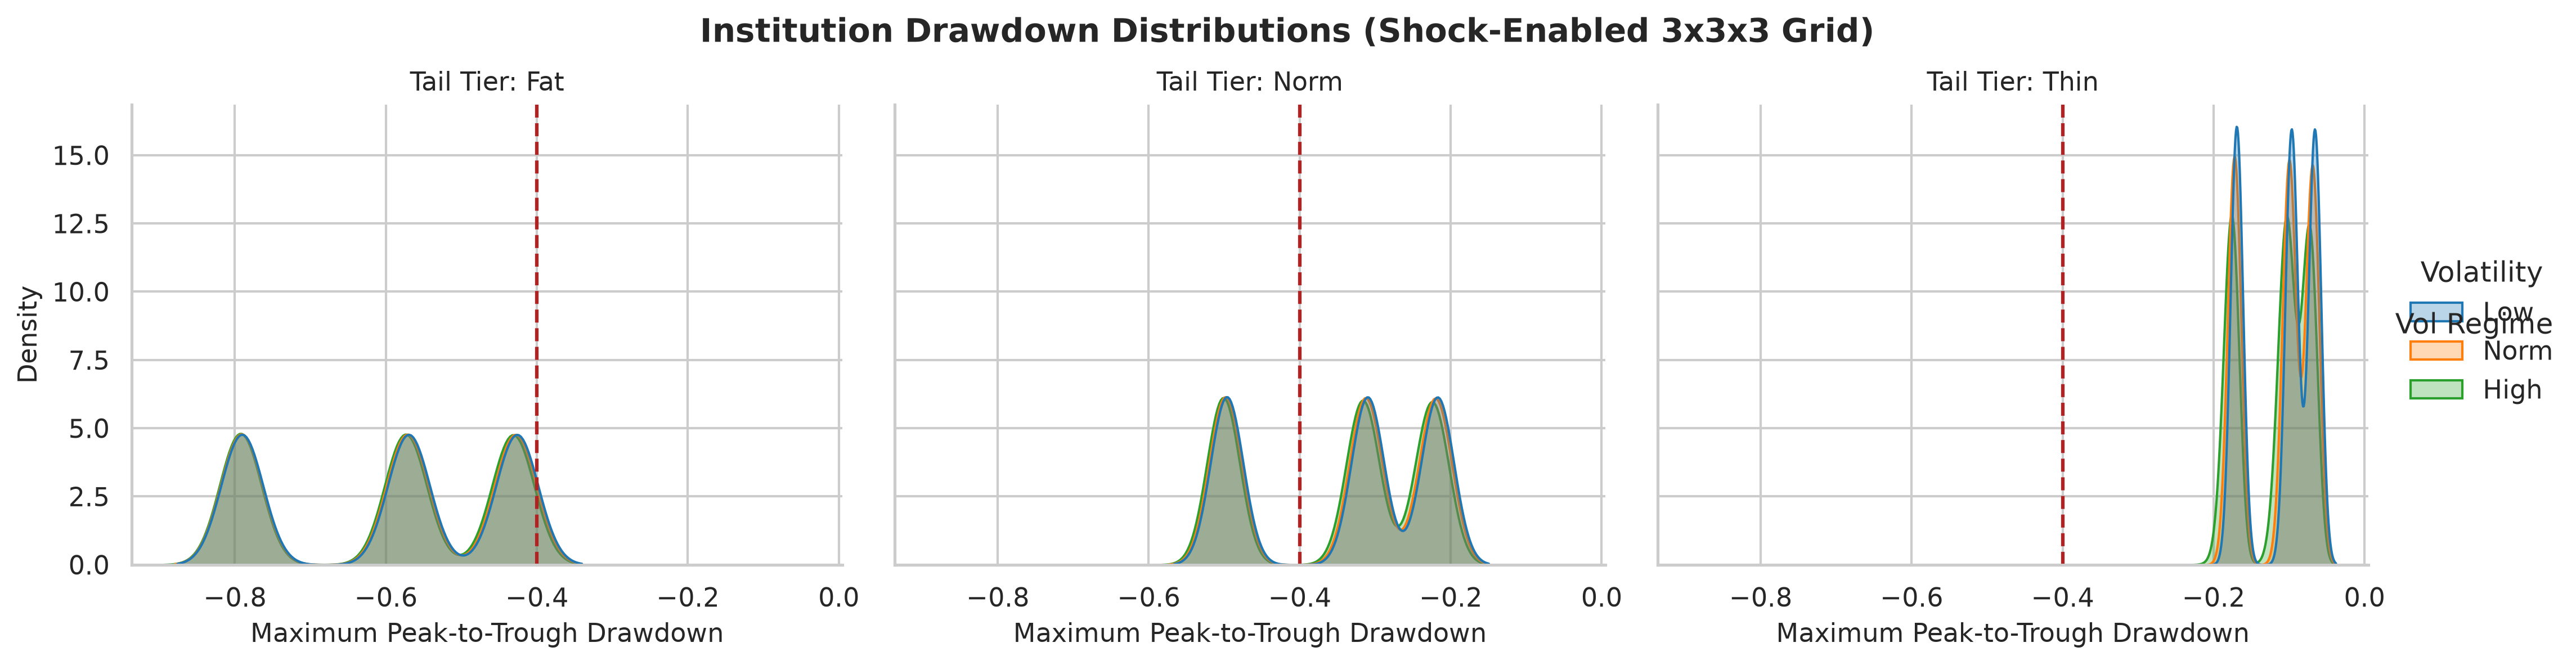

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style configuration
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "axes.labelsize": 11,
        "axes.titlesize": 12,
    }
)


def generate_drawdown_plot() -> None:
    grid = generate_parameter_grid()
    records: list[dict[str, float | str]] = []

    print(
        "Compiling path-wise maximum drawdowns across 3x3x3 grid for"
        " visualization..."
    )
    for _, profile in grid.items():
        # Run shock engine to gather distribution arrays
        _, max_drawdowns = run_shock_monte_carlo(profile, n_paths=1500, n_days=90)
        for dd in max_drawdowns:
            records.append(
                {
                    "Max_Drawdown": dd,
                    "Volatility": profile["Vol_Tier"],
                    "Tail_Thickness": profile["Tail_Tier"],
                    "Asymmetry": profile["Asym_Tier"],
                }
            )

    df_viz = pd.DataFrame(records)

    # Plot distribution grids via Seaborn Displot
    g = sns.displot(
        df_viz,
        x="Max_Drawdown",
        hue="Volatility",
        col="Tail_Thickness",
        kind="kde",
        fill=True,
        common_norm=False,
        alpha=0.3,
        palette="tab10",
        height=4,
        aspect=1.1,
    )

    # Highlight the -40% distress threshold line on all subplots
    for ax in g.axes.flat:
        ax.axvline(
            x=-0.40,
            color="firebrick",
            linestyle="--",
            linewidth=1.5,
            label="40% Distress Threshold",
        )
        ax.set_xlabel("Maximum Peak-to-Trough Drawdown")
        ax.set_ylabel("Density")

    g.set_titles(col_template="Tail Tier: {col_name}")
    g.add_legend(title="Vol Regime")
    plt.subplots_adjust(top=0.85)
    g.fig.suptitle(
        "Institution Drawdown Distributions (Shock-Enabled 3x3x3 Grid)",
        fontsize=14,
        fontweight="bold",
    )

    output_path = "../monte_carlo_drawdown_distributions.png"
    plt.savefig(output_path, bbox_inches="tight")
    print(f"Visualization successfully saved to '{output_path}'")
    plt.show()


generate_drawdown_plot()

Extracting path distributions for all 27 individual institution profiles...
27-grid visualization successfully saved to '../monte_carlo_27_grid_distributions.png'


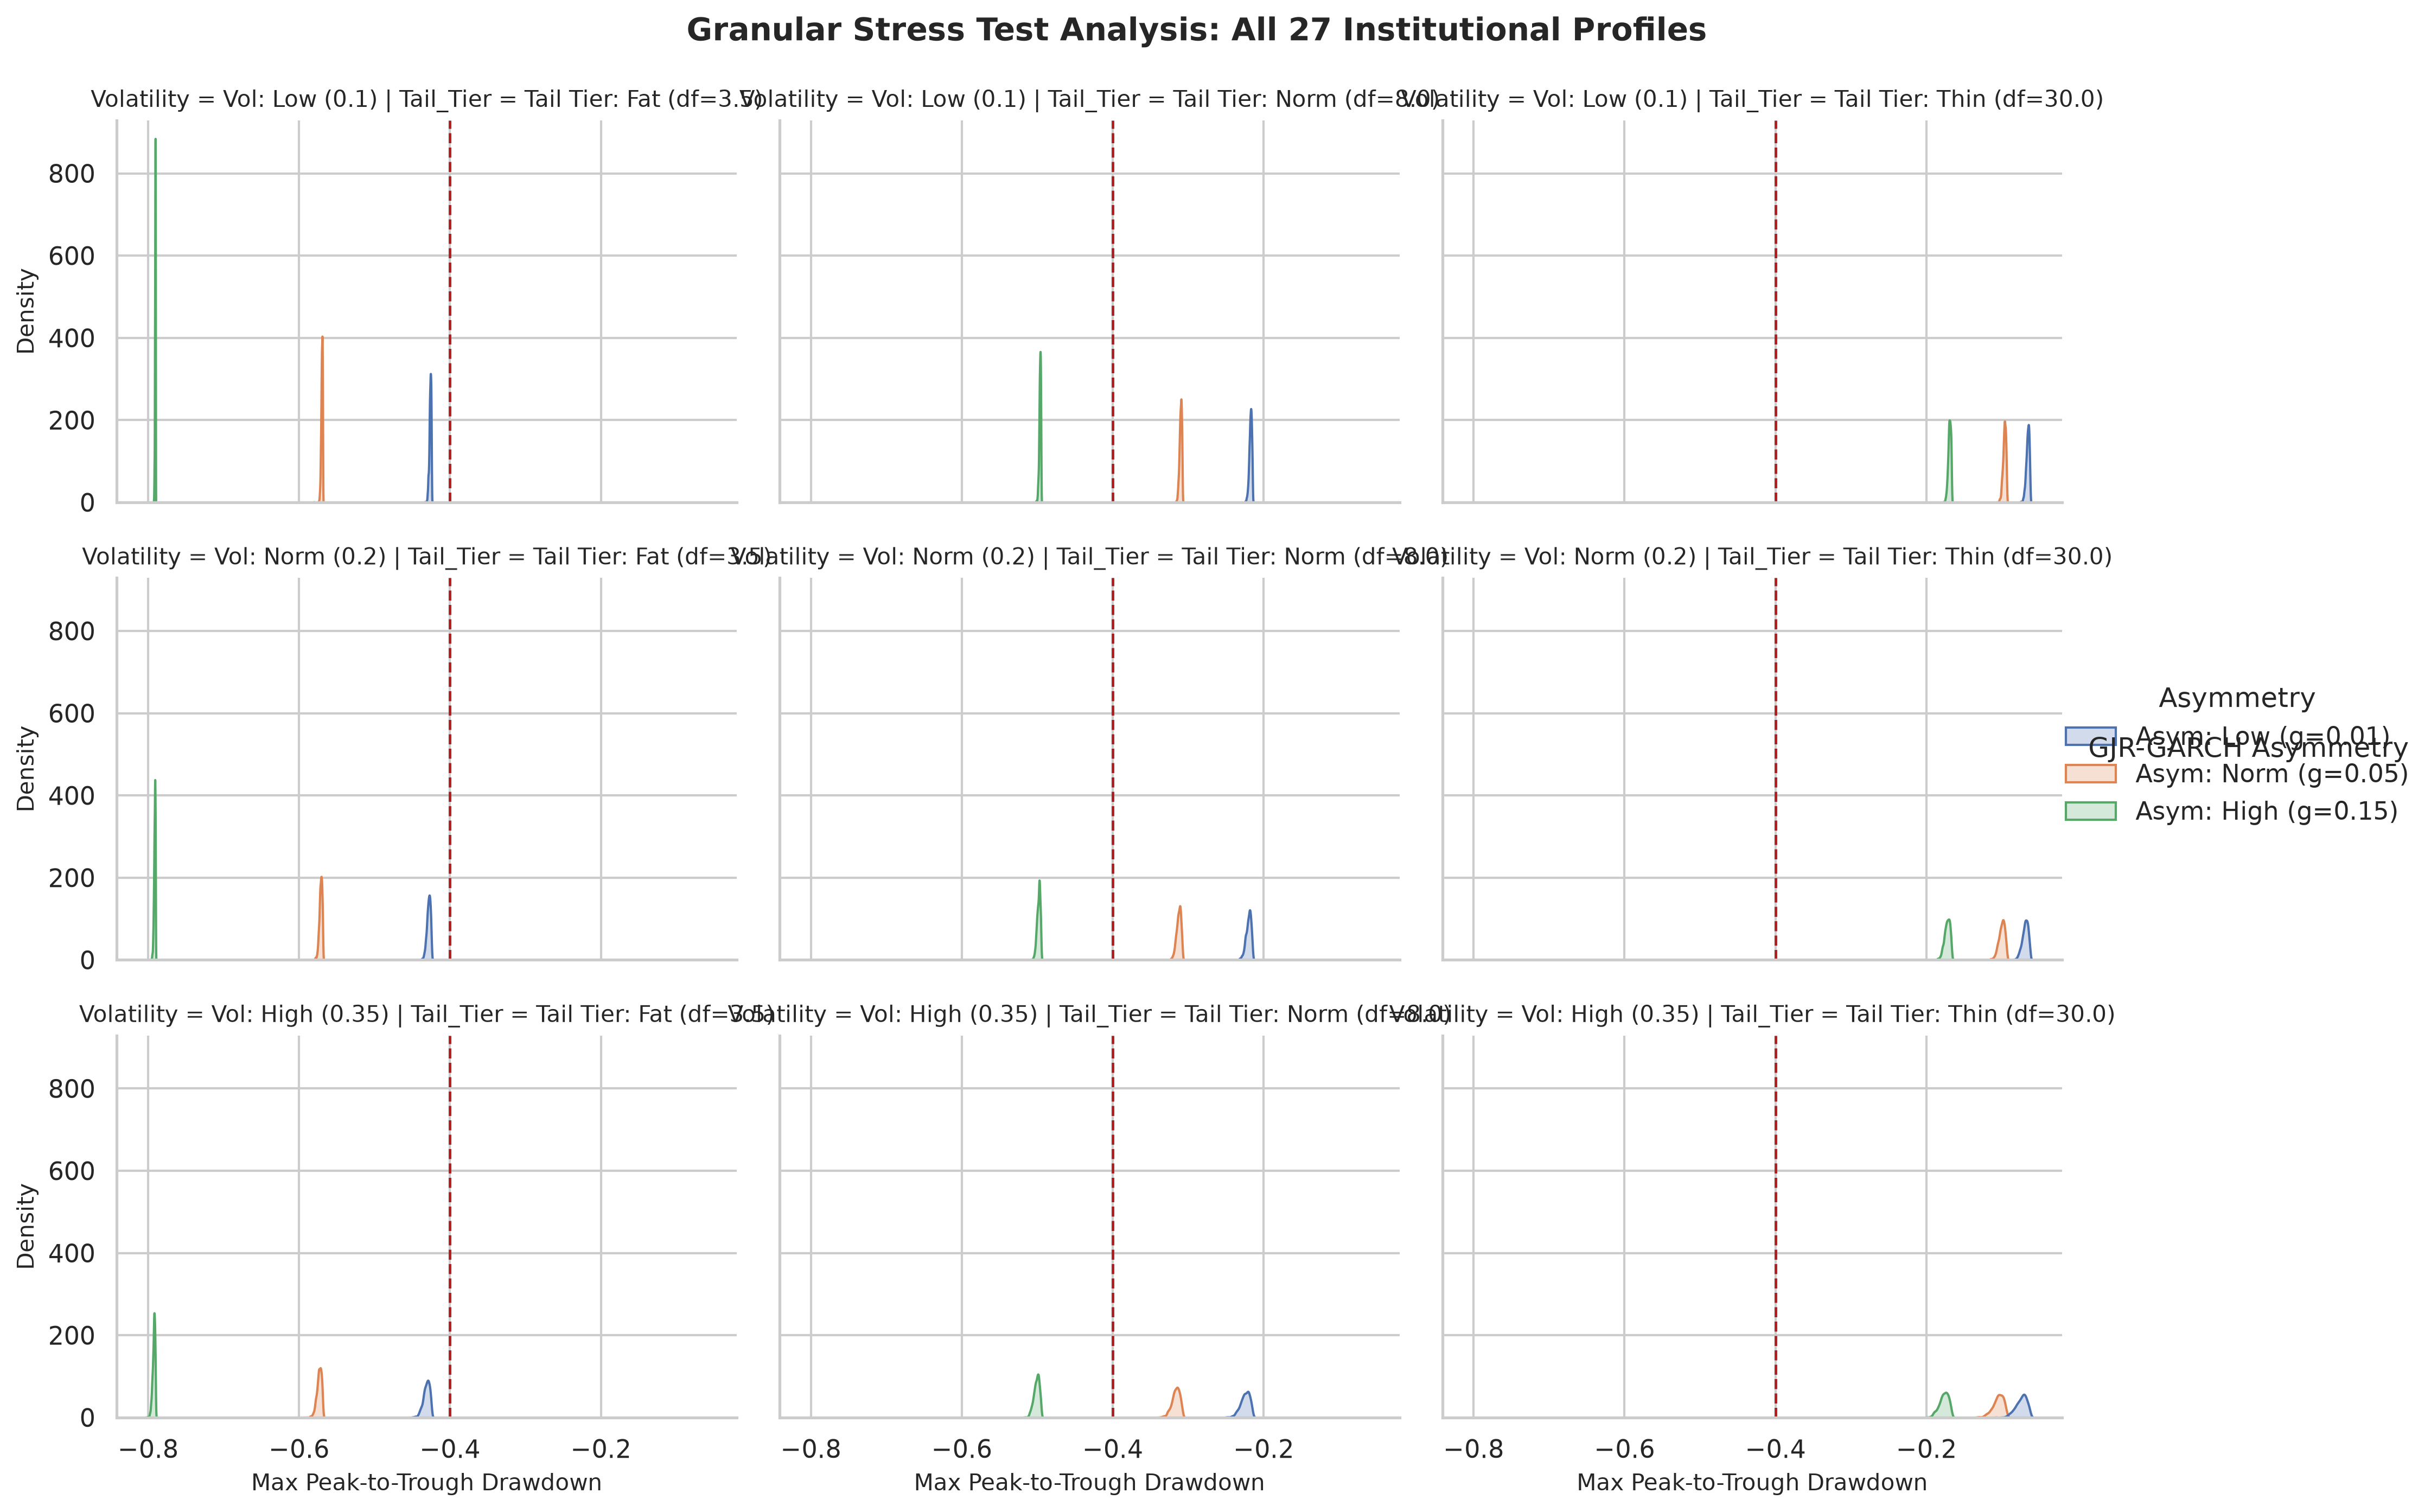

In [ ]:
# individual graphs

import matplotlib.pyplot as plt
import seaborn as sns

# Set publication-grade styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "axes.labelsize": 10,
        "axes.titlesize": 11,
    }
)


def generate_27_grid_plot() -> None:
    grid = generate_parameter_grid()
    records: list[dict[str, float | str]] = []

    print(
        "Extracting path distributions for all 27 individual institution" " profiles..."
    )
    for inst_name, profile in grid.items():
        _, max_drawdowns = run_shock_monte_carlo(profile, n_paths=1500, n_days=90)
        for dd in max_drawdowns:
            records.append(
                {
                    "Max_Drawdown": dd,
                    "Institution": inst_name,
                    "Volatility": f"{profile['Vol_Tier']} ({profile['annual_vol']})",
                    "Tail_Tier": f"{profile['Tail_Tier']} (df={profile['t_df']})",
                    "Asymmetry": (f"{profile['Asym_Tier']} (g={profile['gjr_gamma']})"),
                }
            )

    df_viz = pd.DataFrame(records)

    # Create a FacetGrid mapping Volatility (rows) vs Tail Thickness (cols), colored by Asymmetry
    g = sns.displot(
        df_viz,
        x="Max_Drawdown",
        hue="Asymmetry",
        col="Tail_Tier",
        row="Volatility",
        kind="kde",
        fill=True,
        common_norm=False,
        alpha=0.25,
        palette="deep",
        height=3.0,
        aspect=1.2,
    )

    # Highlight the -40% distress threshold across every single subplot
    for ax in g.axes.flat:
        ax.axvline(
            x=-0.40,
            color="firebrick",
            linestyle="--",
            linewidth=1.2,
            label="40% Distress Threshold",
        )
        ax.set_xlabel("Max Peak-to-Trough Drawdown")
        ax.set_ylabel("Density")

    g.add_legend(title="GJR-GARCH Asymmetry")
    g.fig.suptitle(
        "Granular Stress Test Analysis: All 27 Institutional Profiles",
        y=1.03,
        fontsize=14,
        fontweight="bold",
    )

    output_path = "../monte_carlo_27_grid_distributions.png"
    plt.savefig(output_path)
    print(f"27-grid visualization successfully saved to '{output_path}'")
    plt.show()


generate_27_grid_plot()